# Hybrid Polynomial Solver


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

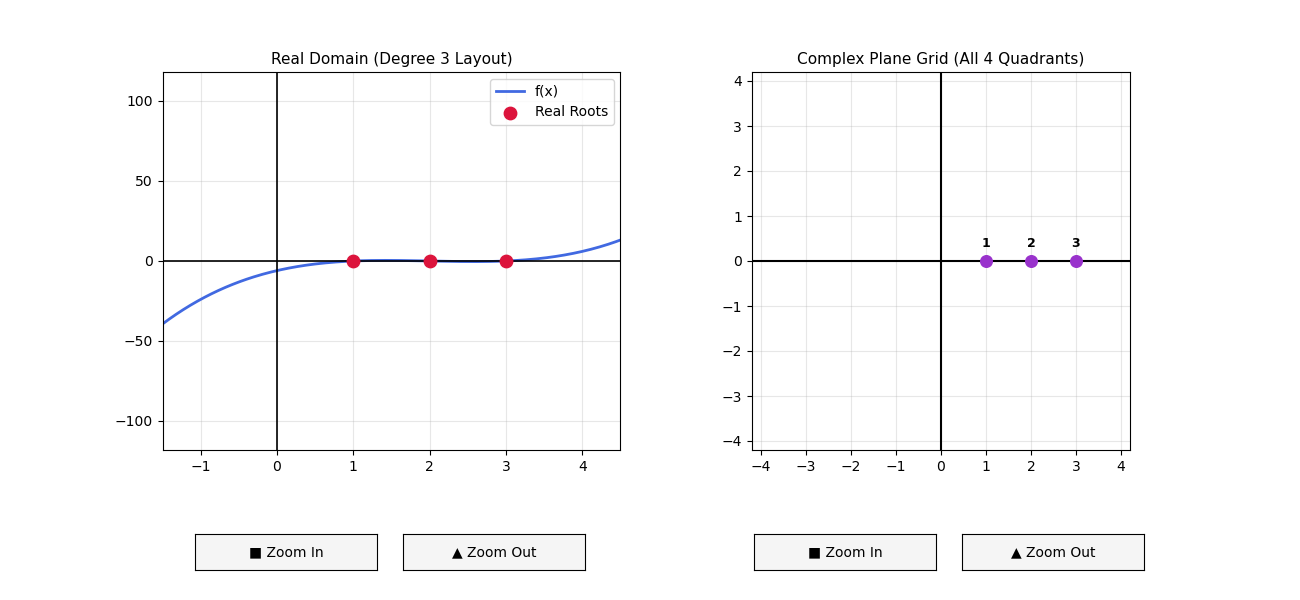

RuntimeError: Another Axes already grabs mouse input

In [11]:
# %%
%matplotlib widget

import re
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from IPython.display import display, Math

# =====================================================================
# CONFIGURATION BOX: Input any equation string here!
# =====================================================================
EQUATION_STRING = "x^3 - 6x^2 + 11x - 6"

PRE_GUESSES = [0.1, 1j * 0.5, -1.0, 1.0 + 1j, -0.5 - 1j * 0.5, 2.0, 0.0]
# =====================================================================


def parse_equation(eq_str):
    eq_str = eq_str.replace(" ", "")
    if "=0" in eq_str:
        eq_str = eq_str.split("=0")[0]
    eq_str = eq_str.replace("-", "+-")
    terms = eq_str.split("+")
    poly_dict = {}
    max_degree = 0
    for term in terms:
        if not term: continue
        coeff = 1.0
        degree = 0
        if 'x' in term:
            if '^' in term:
                base, pwr = term.split('x^')
                degree = int(pwr)
            else:
                base = term.split('x')[0]
                degree = 1
            if base == "" or base == "+": coeff = 1.0
            elif base == "-": coeff = -1.0
            else: coeff = float(base)
        else:
            coeff = float(term)
            degree = 0
        poly_dict[degree] = poly_dict.get(degree, 0.0) + coeff
        if degree > max_degree: max_degree = degree
    coeffs = [0.0] * (max_degree + 1)
    for deg, coeff in poly_dict.items():
        coeffs[max_degree - deg] = coeff
    return coeffs


def evaluate_poly(coeffs, x):
    n = len(coeffs) - 1
    p = coeffs[0]
    dp = 0
    for i in range(1, n + 1):
        dp = dp * x + p
        p = p * x + coeffs[i]
    return p, dp


def find_single_converged_root(coeffs, user_guesses, max_iter=1000, tol=1e-11):
    for base_guess in user_guesses:
        x = complex(base_guess)
        for _ in range(max_iter):
            p, dp = evaluate_poly(coeffs, x)
            if abs(dp) < 1e-15: break
            dx = p / dp
            x -= dx
            if abs(dx) < tol:
                final_p, _ = evaluate_poly(coeffs, x)
                if abs(final_p) < 1e-8: return x
                break
    random.seed(42)
    for _ in range(500):
        x = complex(random.uniform(-5, 5), random.uniform(-5, 5))
        for _ in range(100):
            p, dp = evaluate_poly(coeffs, x)
            if abs(dp) < 1e-15: break
            dx = p / dp
            x -= dx
            if abs(dx) < tol:
                final_p, _ = evaluate_poly(coeffs, x)
                if abs(final_p) < tol: return x
                break
    return x


def deflate_poly(coeffs, root):
    n = len(coeffs) - 1
    new_coeffs = [0] * n
    new_coeffs[0] = coeffs[0]
    for i in range(1, n):
        new_coeffs[i] = coeffs[i] + new_coeffs[i-1] * root
    return new_coeffs


def solve_polynomial(coeffs, guesses):
    current_coeffs = [complex(c) for c in coeffs]
    roots = []
    while len(current_coeffs) > 0 and abs(current_coeffs[0]) < 1e-15:
        current_coeffs.pop(0)
    degree = len(current_coeffs) - 1
    for _ in range(degree):
        root = find_single_converged_root(current_coeffs, guesses)
        roots.append(root)
        current_coeffs = deflate_poly(current_coeffs, root)
    return roots


def clean_num(val, tol=1e-7):
    if abs(val - round(val)) < tol: return str(int(round(val)))
    formatted = f"{val:.4f}".rstrip('0')
    if formatted.endswith('.'): formatted = formatted[:-1]
    return formatted


def format_complex_latex(z, tol=1e-7):
    real_val = z.real if abs(z.real) > tol else 0.0
    imag_val = z.imag if abs(z.imag) > tol else 0.0
    if imag_val == 0: return clean_num(real_val)
    imag_str = "i" if abs(imag_val - 1.0) < tol else ("-i" if abs(imag_val + 1.0) < tol else f"{clean_num(imag_val)}i")
    if real_val == 0: return imag_str
    return f"{clean_num(real_val)} + {imag_str}" if imag_val > 0 else f"{clean_num(real_val)} - {clean_num(abs(imag_val))}i"


def plot_dashboard(coeffs, roots):
    real_roots = [r.real for r in roots if abs(r.imag) < 1e-5]
    degree = len(coeffs) - 1
    
    # Extra bottom space allocated for custom dashboard buttons
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    plt.subplots_adjust(bottom=0.25)
    
    # --- 1. SET UP REAL PLOT BOUNDS ---
    if real_roots:
        min_r, max_r = min(real_roots), max(real_roots)
        root_span = max_r - min_r
        x_pad = max(1.5, root_span * 0.6) if degree <= 3 else max(1.0, root_span * 0.3)
        y_scale_factor = 3.0 if degree <= 3 else 1.5
        x_min, x_max = min_r - x_pad, max_r + x_pad
    else:
        x_min, x_max = -4.0, 4.0
        y_scale_factor = 5.0

    x_min, x_max = min(x_min, -1.5), max(x_max, 1.5)
    
    x_extended = np.linspace(x_min - 20, x_max + 20, 2000)
    y_extended = np.array([evaluate_poly(coeffs, x)[0].real for x in x_extended])
    
    ax1.plot(x_extended, y_extended, color='royalblue', linewidth=2, label='f(x)', clip_on=True)
    if real_roots:
        ax1.scatter(real_roots, [0]*len(real_roots), color='crimson', zorder=5, s=80, label='Real Roots')
        
    ax1.axhline(0, color='black', linestyle='-', linewidth=1.2)
    ax1.axvline(0, color='black', linestyle='-', linewidth=1.2)
    
    visible_x = np.linspace(x_min, x_max, 300)
    visible_y = np.array([evaluate_poly(coeffs, x)[0].real for x in visible_x])
    y_max_bound = max(5.0, np.max(np.abs(visible_y)) * y_scale_factor)
    
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(-y_max_bound, y_max_bound)
    ax1.set_title(f"Real Domain (Degree {degree} Layout)", fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # --- 2. SET UP COMPLEX PLOT BOUNDS ---
    real_parts = [r.real for r in roots]
    imag_parts = [r.imag for r in roots]
    
    ax2.scatter(real_parts, imag_parts, color='darkorchid', zorder=5, s=70, label='Roots')
    ax2.axhline(0, color='black', linestyle='-', linewidth=1.5)
    ax2.axvline(0, color='black', linestyle='-', linewidth=1.5)
    
    for r in roots:
        lbl = f"({clean_num(r.real)}, {clean_num(r.imag)}i)" if abs(r.imag) > 1e-5 else f"{clean_num(r.real)}"
        ax2.annotate(lbl, (r.real, r.imag), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, weight='bold')

    all_coordinates = real_parts + imag_parts
    max_val = max(max(abs(p) for p in all_coordinates), 3.0) * 1.4
    
    ax2.set_xlim(-max_val, max_val)
    ax2.set_ylim(-max_val, max_val)
    ax2.set_title("Complex Plane Grid (All 4 Quadrants)", fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

    # --- 3. INJECT CUSTOM SQUARE / TRIANGLE BUTTONS ---
    # Layout slots under Real Plot
    ax_in_1 = plt.axes([0.15, 0.05, 0.14, 0.06])
    ax_out_1 = plt.axes([0.31, 0.05, 0.14, 0.06])
    
    # Layout slots under Complex Plot
    ax_in_2 = plt.axes([0.58, 0.05, 0.14, 0.06])
    ax_out_2 = plt.axes([0.74, 0.05, 0.14, 0.06])
    
    # Labels matching shapes
    btn_in_1 = Button(ax_in_1, '■ Zoom In', color='whitesmoke', hovercolor='lightgray')
    btn_out_1 = Button(ax_out_1, '▲ Zoom Out', color='whitesmoke', hovercolor='lightgray')
    btn_in_2 = Button(ax_in_2, '■ Zoom In', color='whitesmoke', hovercolor='lightgray')
    btn_out_2 = Button(ax_out_2, '▲ Zoom Out', color='whitesmoke', hovercolor='lightgray')
    
    # Real Axis Actions
    def zoom_in_real(event):
        xl, xr = ax1.get_xlim()
        yb, yt = ax1.get_ylim()
        xc, yc = (xl + xr)/2, (yb + yt)/2
        xh, yh = (xr - xl)*0.33, (yt - yb)*0.33
        ax1.set_xlim(xc - xh, xc + xh)
        ax1.set_ylim(yc - yh, yc + yh)
        fig.canvas.draw_idle()

    def zoom_out_real(event):
        xl, xr = ax1.get_xlim()
        yb, yt = ax1.get_ylim()
        xc, yc = (xl + xr)/2, (yb + yt)/2
        xh, yh = (xr - xl)*0.75, (yt - yb)*0.75
        ax1.set_xlim(xc - xh, xc + xh)
        ax1.set_ylim(yc - yh, yc + yh)
        fig.canvas.draw_idle()

    # Complex Axis Actions (Locks aspect ratios)
    def zoom_in_complex(event):
        cl, cr = ax2.get_xlim()
        ch = (cr - cl) * 0.33
        ax2.set_xlim(-ch, ch)
        ax2.set_ylim(-ch, ch)
        fig.canvas.draw_idle()

    def zoom_out_complex(event):
        cl, cr = ax2.get_xlim()
        ch = (cr - cl) * 0.75
        ax2.set_xlim(-ch, ch)
        ax2.set_ylim(-ch, ch)
        fig.canvas.draw_idle()

    # Bind click callbacks
    btn_in_1.on_clicked(zoom_in_real)
    btn_out_1.on_clicked(zoom_out_real)
    btn_in_2.on_clicked(zoom_in_complex)
    btn_out_2.on_clicked(zoom_out_complex)
    
    # Store global references to keep widget engine instances alive
    ax1.ref_in, ax1.ref_out = btn_in_1, btn_out_1
    ax2.ref_in, ax2.ref_out = btn_in_2, btn_out_2

    plt.show()


def run_complete_solver(eq_str, guesses):
    coeffs = parse_equation(eq_str)
    degree = len(coeffs) - 1
    eq_parts = []
    for i, c in enumerate(coeffs):
        pwr = degree - i
        if c == 0: continue
        sign = " + " if c > 0 else " - "
        if i == 0: sign = "" if c > 0 else "-"
        val = abs(c)
        val_str = "" if (val == 1 and pwr > 0) else clean_num(val)
        if pwr > 1: eq_parts.append(f"{sign}{val_str}x^{{{pwr}}}")
        elif pwr == 1: eq_parts.append(f"{sign}{val_str}x")
        else: eq_parts.append(f"{sign}{val_str}")
            
    eq_latex = "".join(eq_parts) + " = 0"
    roots = solve_polynomial(coeffs, guesses)
    roots.sort(key=lambda r: (abs(r.imag) > 1e-5, r.real))
    
    display(Math(f"\\LARGE {{{eq_latex}}}"))
    answers_latex = "\\LARGE {\\begin{aligned}"
    for idx, r in enumerate(roots, 1):
        answers_latex += f"x_{{{idx}}} &= {format_complex_latex(r)} \\\\"
    answers_latex += "\\end{aligned}}"
    display(Math(answers_latex))
    
    plot_dashboard(coeffs, roots)


run_complete_solver(EQUATION_STRING, PRE_GUESSES)